<a href="https://colab.research.google.com/github/ciril7/AI-ML-Intern/blob/main/Walmart_Sales_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
import numpy as np
from scipy.stats import skew
import seaborn as sns

In [2]:
df=pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")


In [3]:
encoder_data=df.copy()

In [4]:
df['Weekly_Sales_mean_imputed']=df['Weekly_Sales'].fillna(df['Weekly_Sales'])

In [5]:
df['Weekly_Sales_median_imputed']=df['Weekly_Sales'].fillna(df['Weekly_Sales'].median())
df['Temperature_mode_imputed']=df['Temperature'].fillna(df['Temperature'].mode()[0])

In [6]:
df[['Weekly_Sales','Weekly_Sales_mean_imputed','Weekly_Sales_median_imputed']]

,Weekly_Sales,Weekly_Sales_mean_imputed,Weekly_Sales_median_imputed
0,1643690.90,1643690.90,1643690.90
1,1641957.44,1641957.44,1641957.44
2,1611968.17,1611968.17,1611968.17
3,1409727.59,1409727.59,1409727.59
4,1554806.68,1554806.68,1554806.68
...,...,...,...
6430,713173.95,713173.95,713173.95
6431,733455.07,733455.07,733455.07
6432,734464.36,734464.36,734464.36
6433,718125.53,718125.53,718125.53


In [7]:
sns.set(style="whitegrid")


/tmp/ipykernel_8748/436468022.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Holiday_Flag',y='Temperature',palette='muted')


Text(0, 0.5, 'Temperature')

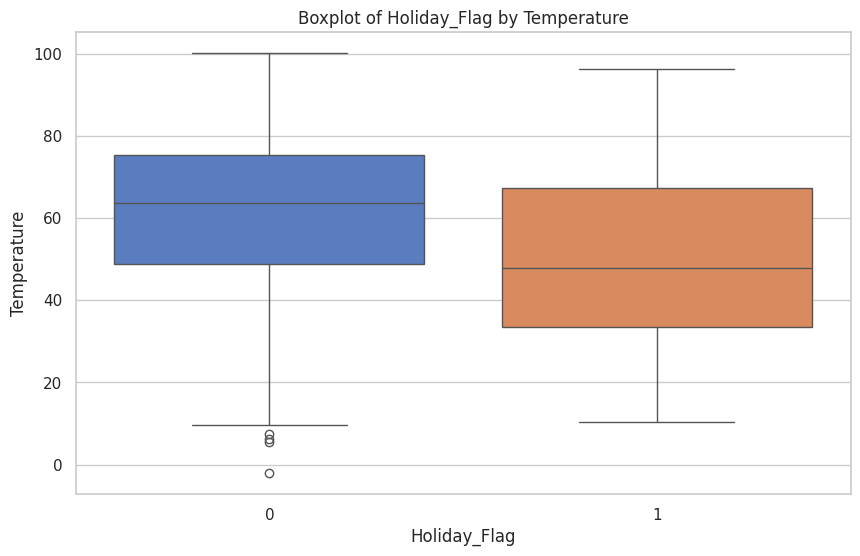

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='Holiday_Flag',y='Temperature',palette='muted')
plt.title('Boxplot of Holiday_Flag by Temperature')
plt.xlabel('Holiday_Flag')
plt.ylabel('Temperature')

/tmp/ipykernel_8748/645373460.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x='Holiday_Flag',y='Temperature',palette='muted')


Text(0, 0.5, 'Temperature')

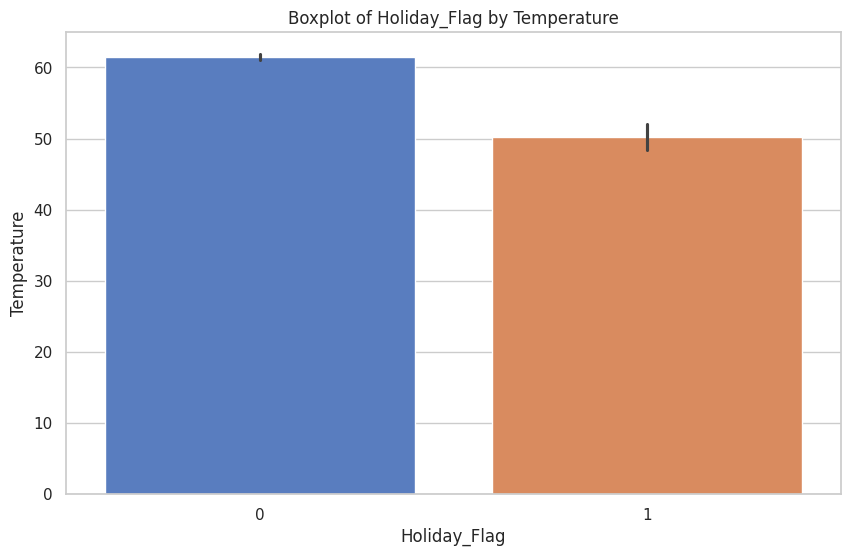

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='Holiday_Flag',y='Temperature',palette='muted')
plt.title('Boxplot of Holiday_Flag by Temperature')
plt.xlabel('Holiday_Flag')
plt.ylabel('Temperature')

/tmp/ipykernel_8748/2230514473.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df,x='Holiday_Flag',y='Temperature',palette='muted')


Text(0, 0.5, 'Temperature')

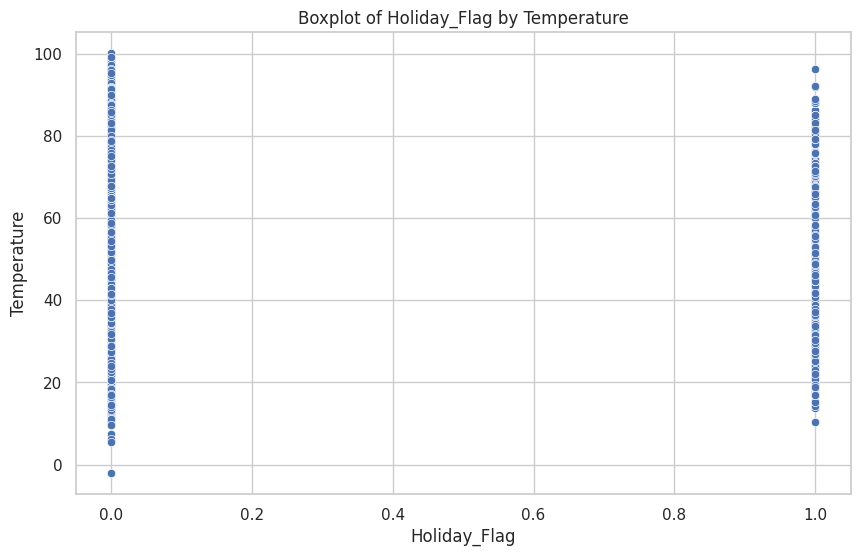

In [10]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Holiday_Flag',y='Temperature',palette='muted')
plt.title('Boxplot of Holiday_Flag by Temperature')
plt.xlabel('Holiday_Flag')
plt.ylabel('Temperature')

/tmp/ipykernel_8748/1139422128.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=df,x='Holiday_Flag',y='Temperature',palette='muted')


Text(0, 0.5, 'Temperature')

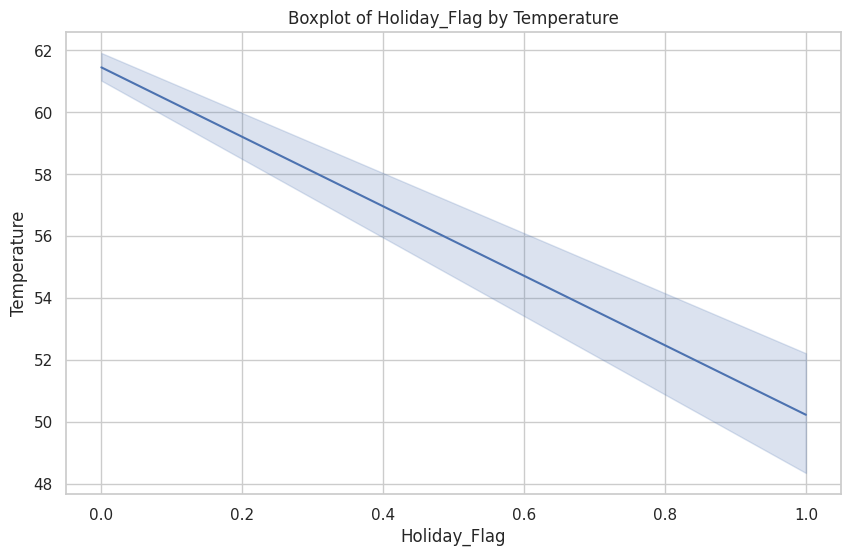

In [11]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df,x='Holiday_Flag',y='Temperature',palette='muted')
plt.title('Boxplot of Holiday_Flag by Temperature')
plt.xlabel('Holiday_Flag')
plt.ylabel('Temperature')

/tmp/ipykernel_8748/2745686605.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df,x='Holiday_Flag',y='Temperature',palette='muted')


Text(0, 0.5, 'Temperature')

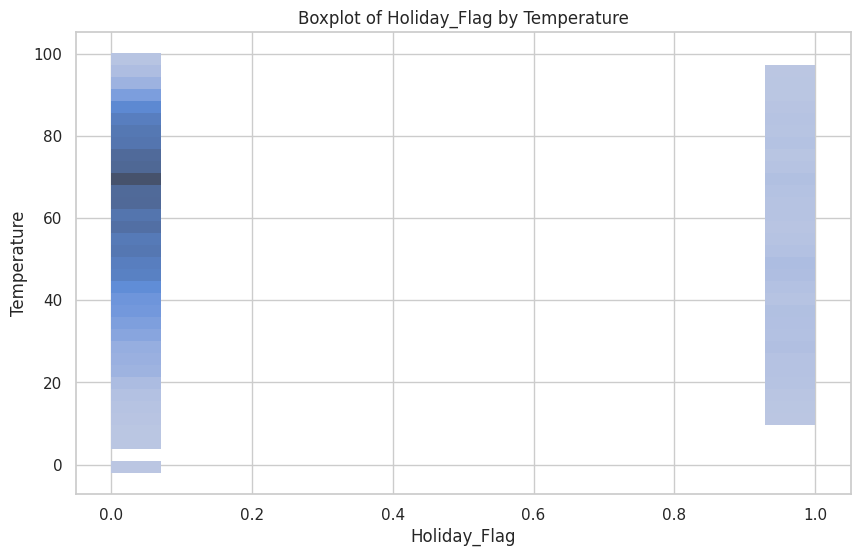

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='Holiday_Flag',y='Temperature',palette='muted')
plt.title('Boxplot of Holiday_Flag by Temperature')
plt.xlabel('Holiday_Flag')
plt.ylabel('Temperature')

In [13]:
import pandas as pd
df["Date"] = pd.to_datetime(df["Date"],format="%d-%m-%Y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df[['Day','Month','Year']].head()

,Day,Month,Year
0,5,2,2010
1,12,2,2010
2,19,2,2010
3,26,2,2010
4,5,3,2010


In [14]:
numerical_columns=['Weekly_Sales']

In [15]:
minmax_scaler=MinMaxScaler()


In [16]:


df['Weekly_Sales_MinMax']=minmax_scaler.fit_transform(df[['Weekly_Sales']])






In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales","Date"])  # All columns except target
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 1.0000
RMSE: 0.0000


<function matplotlib.pyplot.show(close=None, block=None)>

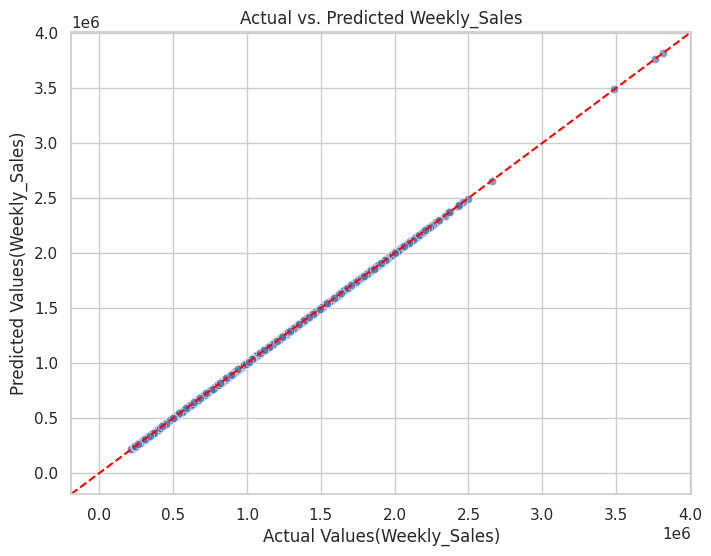

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('Actual Values(Weekly_Sales)')
plt.ylabel('Predicted Values(Weekly_Sales)')
plt.title('Actual vs. Predicted Weekly_Sales')
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show

In [19]:
from scipy.stats import skew



In [20]:
skewness = df.select_dtypes(include=np.number).skew()

In [21]:
import numpy as np
skewed_cols=df.select_dtypes(include=np.number).skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly Skewed Columns:\n",highly_skewed)
print("Negatively Skewed Columns:\n",negatively_skewed)

Highly Skewed Columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively Skewed Columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
       'Weekly_Sales_mean_imputed', 'Weekly_Sales_median_imputed',
       'Temperature_mode_imputed', 'Year', 'Month', 'Day',
       'Weekly_Sales_MinMax'],
      dtype='object')


In [22]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))


In [23]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
# Drop 'Weekly_Sales' (the target itself), 'Date', and any columns directly derived from 'Weekly_Sales'
X = df.drop(columns=["Weekly_Sales","Date", "Weekly_Sales_mean_imputed", "Weekly_Sales_median_imputed", "Weekly_Sales_MinMax"])
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1336
RMSE: 0.9428


<function matplotlib.pyplot.show(close=None, block=None)>

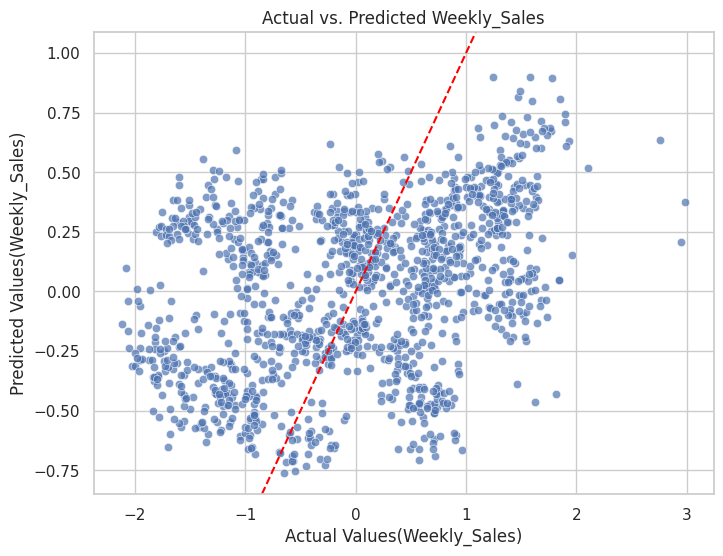

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('Actual Values(Weekly_Sales)')
plt.ylabel('Predicted Values(Weekly_Sales)')
plt.title('Actual vs. Predicted Weekly_Sales')
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show


In [26]:
new_skewness = df.select_dtypes(include=np.number).skew()

In [27]:
import numpy as np
skewed_cols=df.select_dtypes(include=np.number).skew().abs()
highly_skewed=skewed_cols[skewed_cols>1].index
negatively_skewed=skewed_cols[skewed_cols<1].index
print("Highly Skewed Columns:\n",highly_skewed)
print("Negatively Skewed Columns:\n",negatively_skewed)

Highly Skewed Columns:
 Index(['Holiday_Flag'], dtype='object')
Negatively Skewed Columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
       'Unemployment', 'Weekly_Sales_mean_imputed',
       'Weekly_Sales_median_imputed', 'Temperature_mode_imputed', 'Year',
       'Month', 'Day', 'Weekly_Sales_MinMax'],
      dtype='object')


In [28]:
df[highly_skewed]=df[highly_skewed].apply(lambda x:np.log1p(x))

In [29]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
df[negatively_skewed]=pt.fit_transform(df[negatively_skewed])

In [30]:
df.select_dtypes(include=np.number).skew()

,0
Store,-0.043855
Weekly_Sales,0.007710
Holiday_Flag,3.373499
Temperature,-0.011073
Fuel_Price,0.015640
CPI,0.009450
Unemployment,0.007891
Weekly_Sales_mean_imputed,0.007710
Weekly_Sales_median_imputed,0.007710
Temperature_mode_imputed,-0.011073


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
# Drop 'Weekly_Sales' (the target itself), 'Date', and any columns directly derived from 'Weekly_Sales'
X = df.drop(columns=["Weekly_Sales","Date", "Weekly_Sales_mean_imputed", "Weekly_Sales_median_imputed", "Weekly_Sales_MinMax"])
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1418
RMSE: 0.9378


<function matplotlib.pyplot.show(close=None, block=None)>

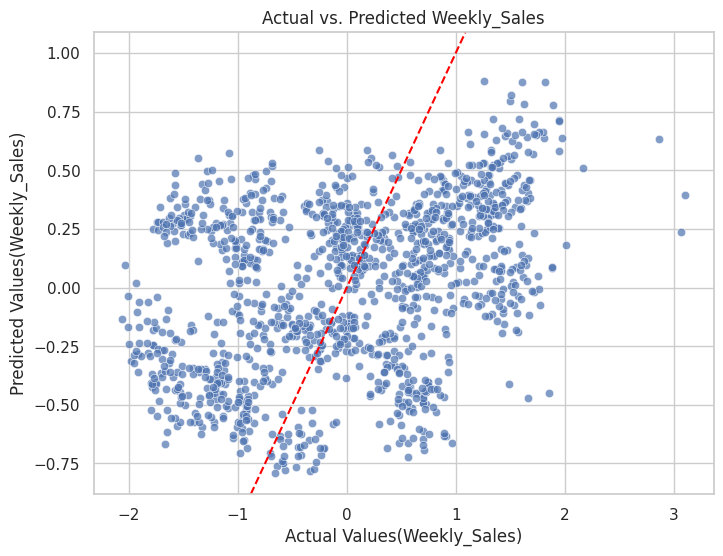

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_pred,alpha=0.7)
plt.xlabel('Actual Values(Weekly_Sales)')
plt.ylabel('Predicted Values(Weekly_Sales)')
plt.title('Actual vs. Predicted Weekly_Sales')
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show